# Sprite World — Visualization

A **single asymmetric sprite** with pose state **(x, y, θ)**, rendered rotated
and **anti-aliased** on a 64×64 white canvas. θ is observable only because the
sprite has no rotational symmetry. Default shape is an **arrow** (`Shape.ARROW`)
— the cleanest orientation cue; `TEARDROP`, `PACMAN`, `HEART` are also selectable
via the config.

Each step samples a delta **(dx, dy, dθ)** for *all three* DOFs from a matched
per-DOF distribution and applies it (θ wraps at 2π). A **control_mask** over
(x, y, θ) selects which deltas are exposed in the **action vector**; unselected
DOFs still move but are **uncontrolled**.

Four nested control configurations:

| config | mask (x, y, θ) | action_dim | exposed DOFs |
|--------|----------------|-----------:|--------------|
| `NONE` | F, F, F        | 0          | —            |
| `X`    | T, F, F        | 1          | x            |
| `XY`   | T, T, F        | 2          | x, y         |
| `XYT`  | T, T, T        | 3          | x, y, θ      |

Each sample is `(obs_t, action, obs_tp1, state_t)` — the same 4-tuple
`train.py` unpacks (`for obs_t, action, obs_tp1, _ in loader`).

In [1]:
import sys
sys.path.insert(0, '..')   # repo root, so `datasets` is importable

import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from datasets.sprite_world import (
    SpriteWorldConfig,
    SpriteWorldDataset,
    ControlConfig,
    Shape,
    make_sprite_config,
    render_sprite,
    generate_trajectory,
    DOF_LABELS,
)

try:
    from misc.plot_style import apply_matplotlib_style
    apply_matplotlib_style()
except Exception:
    pass

## Sprite shapes

All shapes lack rotational symmetry, so θ is uniquely recoverable over [0, 2π).
The arrow gives the strongest, lowest-frequency orientation signal.

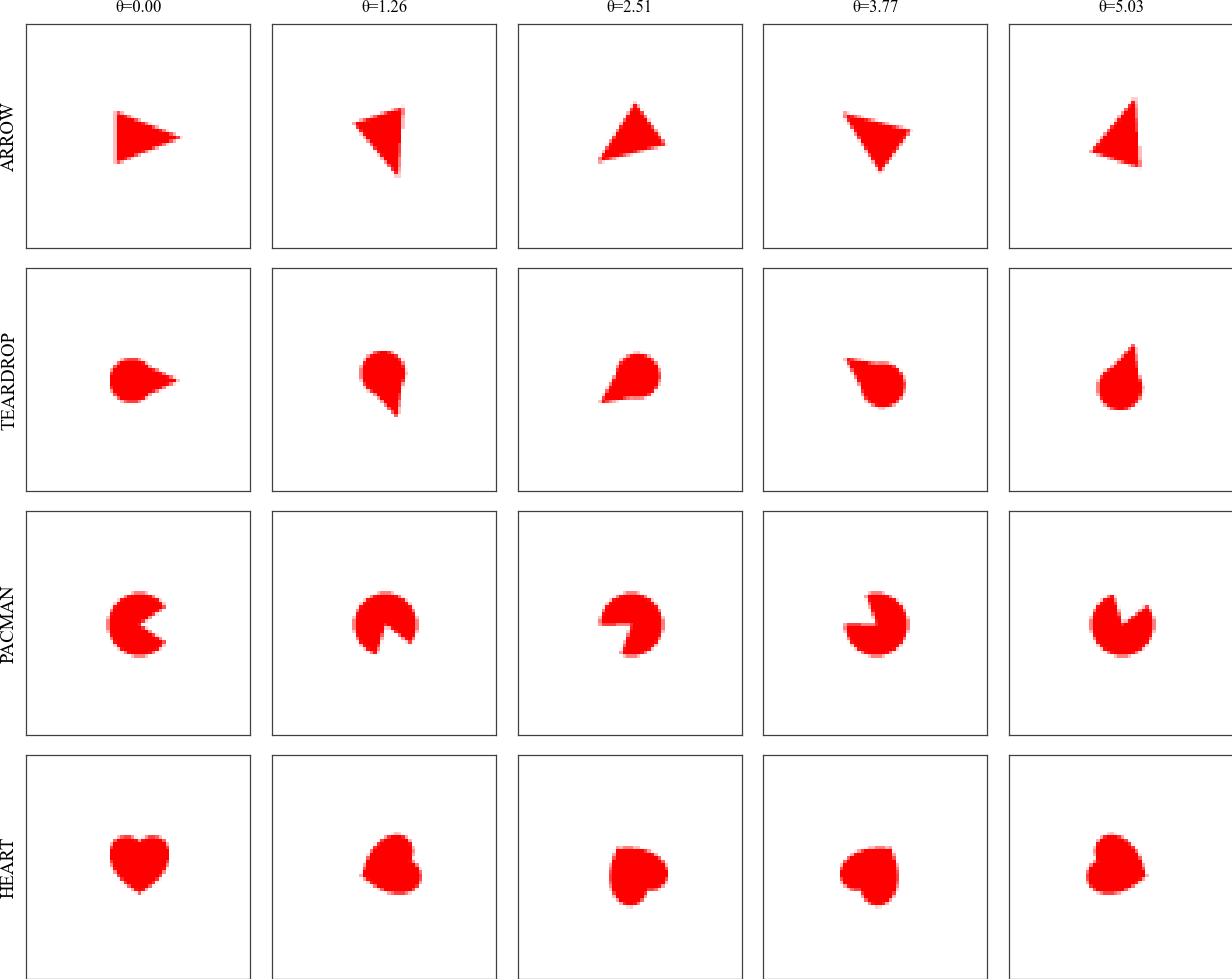

In [2]:
shapes = list(Shape)
angles = np.linspace(0, 2 * np.pi, 5, endpoint=False)
fig, axes = plt.subplots(len(shapes), len(angles),
                         figsize=(1.7 * len(angles), 1.7 * len(shapes)))
for r, sh in enumerate(shapes):
    cfg = make_sprite_config(shape=sh)
    for c, th in enumerate(angles):
        axes[r, c].imshow(render_sprite(np.array([32, 32, th]), cfg).transpose(1, 2, 0),
                          interpolation="nearest")
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0:
            axes[r, c].set_title(f"θ={th:.2f}", fontsize=8)
    axes[r, 0].set_ylabel(sh.name, fontsize=9)
plt.tight_layout()
plt.show()

## Helpers

`full_transition` re-derives the full pose pair and delta for a given index
(using the same seed mapping as `dataset[idx]`), so we can annotate the
*uncontrolled* DOFs that move but are absent from the action vector.

In [3]:
def full_transition(ds, idx):
    """Return obs_t, obs_tp1, state_t, state_tp1, full delta, action for ds[idx]."""
    rng = np.random.default_rng(ds.seed + idx)
    state_t, action, state_tp1 = ds._sample_transition(rng)
    delta = state_tp1 - state_t
    delta[2] = (delta[2] + np.pi) % (2 * np.pi) - np.pi      # wrap dθ to (-π, π]
    obs_t = render_sprite(state_t, ds.config)
    obs_tp1 = render_sprite(state_tp1, ds.config)
    return obs_t, obs_tp1, state_t, state_tp1, delta, action


def _pose(s):
    return f"x={s[0]:5.1f}  y={s[1]:5.1f}  θ={s[2]:4.2f}"


def _vec(v):
    return "[" + ", ".join(f"{x:+.2f}" for x in v) + "]"


def show_transitions_annotated(ds, indices, title=""):
    """obs_t | obs_t+1 side by side with pose and action vector annotated."""
    mask = ds.config.control_mask
    n = len(indices)
    fig, axes = plt.subplots(n, 3, figsize=(8.6, 2.5 * n),
                             gridspec_kw={"width_ratios": [1, 1, 1.7]})
    axes = np.atleast_2d(axes)
    fig.suptitle(title, fontweight="bold", y=1.0)
    for r, idx in enumerate(indices):
        obs_t, obs_tp1, st, stp1, delta, action = full_transition(ds, idx)
        axes[r, 0].imshow(obs_t.transpose(1, 2, 0), interpolation="nearest")
        axes[r, 1].imshow(obs_tp1.transpose(1, 2, 0), interpolation="nearest")
        axes[r, 0].set_title("obs_t", fontsize=9)
        axes[r, 1].set_title("obs_t+1", fontsize=9)
        for c in (0, 1):
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        dof = [f"  Δ{lab} = {delta[k]:+5.2f}   "
               f"({'action' if mask[k] else 'uncontrolled'})"
               for k, lab in enumerate(DOF_LABELS)]
        txt = (f"pose_t   : {_pose(st)}\n"
               f"pose_t+1 : {_pose(stp1)}\n\n"
               f"full delta:\n" + "\n".join(dof) +
               f"\n\naction a = {_vec(action)}  (dim={action.shape[0]})")
        axes[r, 2].axis("off")
        axes[r, 2].text(0.0, 0.5, txt, family="monospace", fontsize=8, va="center")
    plt.tight_layout()
    plt.show()


def plot_random_grid(ds, n_cols=6, seed=0, title=""):
    """Small grid of random sampled transitions (t over t+1), action below."""
    fig, axes = plt.subplots(2, n_cols, figsize=(1.7 * n_cols, 3.7))
    fig.suptitle(title, fontweight="bold", y=1.02)
    for c in range(n_cols):
        obs_t, obs_tp1, st, stp1, delta, action = full_transition(ds, seed + c)
        axes[0, c].imshow(obs_t.transpose(1, 2, 0), interpolation="nearest")
        axes[1, c].imshow(obs_tp1.transpose(1, 2, 0), interpolation="nearest")
        axes[0, c].set_title(f"θ={st[2]:.2f}", fontsize=7)
        axes[1, c].set_xlabel("a=" + _vec(action), fontsize=6)
    for ax in axes.ravel():
        ax.set_xticks([]); ax.set_yticks([])
    axes[0, 0].set_ylabel("t"); axes[1, 0].set_ylabel("t+1")
    plt.tight_layout()
    plt.show()
    print(ds.config.describe(), "\n")

## The four nested control configurations

`action_dim` grows 0 → 3 as more DOFs are exposed, while the *world dynamics*
(all three DOFs always move) stay identical.

In [4]:
print(f'{"config":<6} {"mask (x,y,θ)":<14} {"action_dim":>10}  exposed')
print("-" * 48)
for cc in ControlConfig:
    cfg = make_sprite_config(cc)
    m = cfg.control_mask.astype(int)
    labels = ",".join(cc.controlled_labels) or "—"
    print(f"{cc.name:<6} {str(m):<14} {cfg.action_dim:>10}  {labels}")

config mask (x,y,θ)   action_dim  exposed
------------------------------------------------
NONE   [0 0 0]                 0  —
X      [1 0 0]                 1  x
XY     [1 1 0]                 2  x,y
XYT    [1 1 1]                 3  x,y,θ


## 1 — `NONE`

Fully uncontrolled — `action_dim = 0`. All three DOFs move but none is exposed; the action vector is empty.

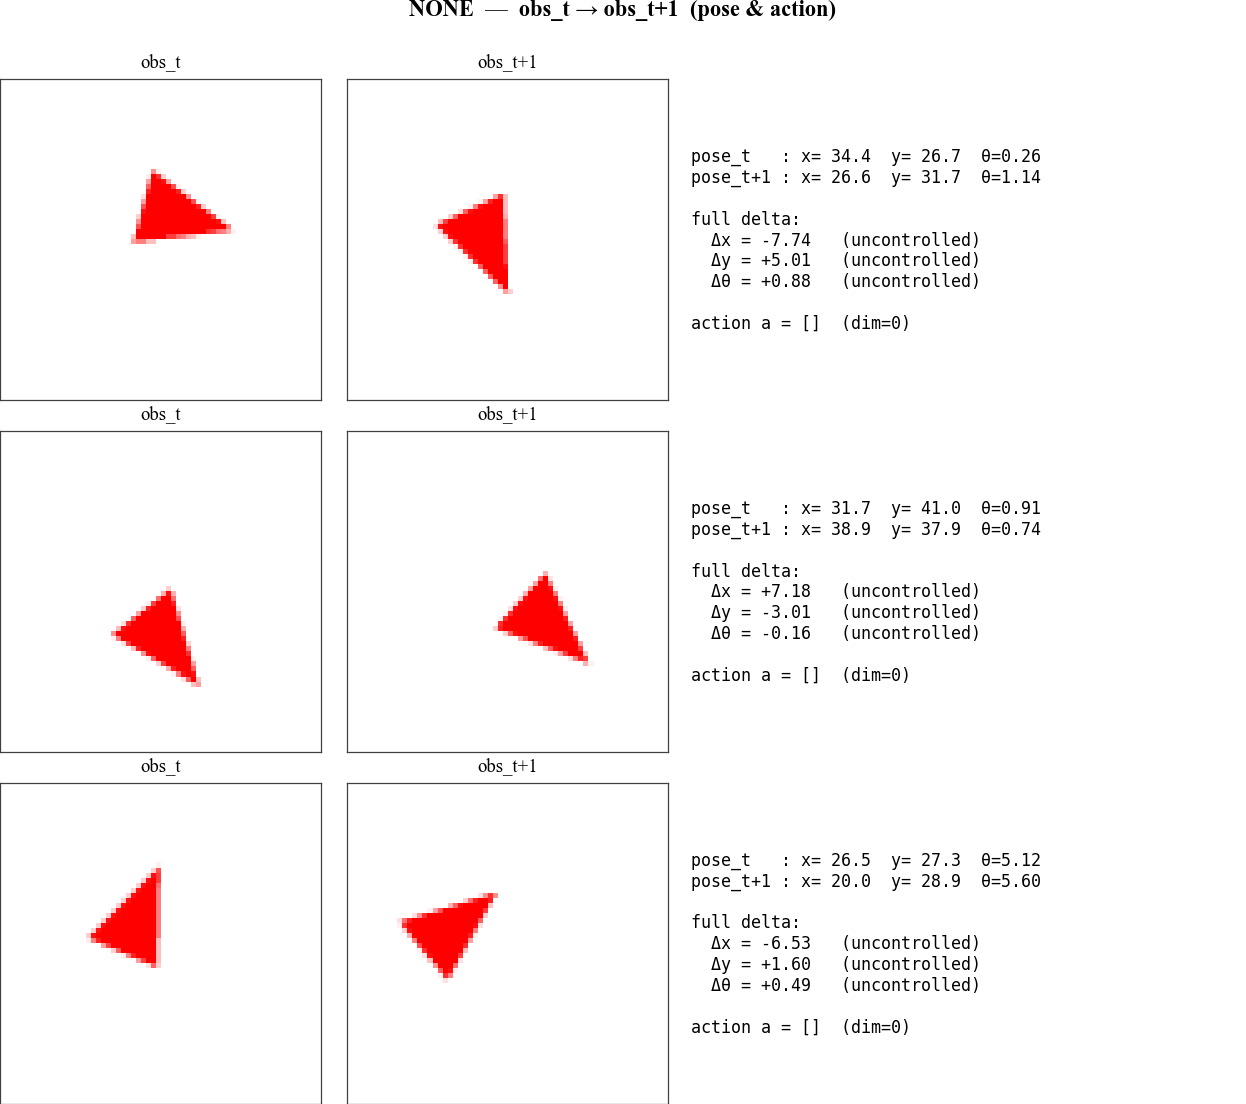

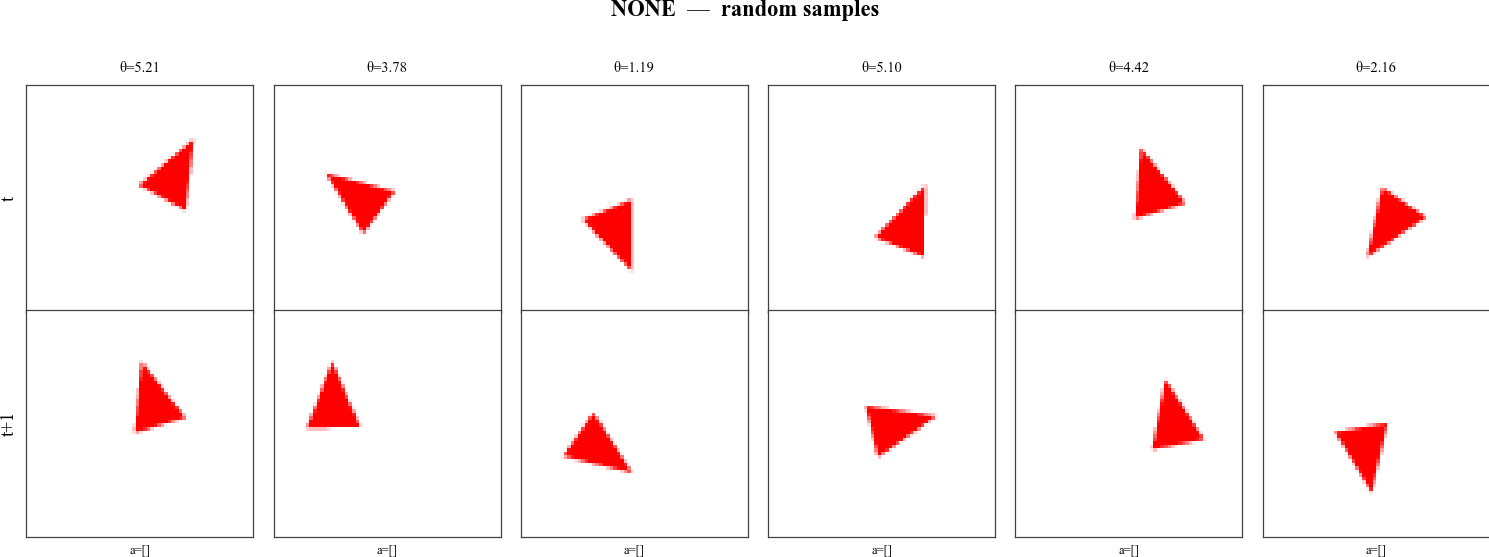

SpriteWorldConfig  |  64×64 px  |  shape=ARROW  sprite_scale=7.5  |  control=NONE (—)  |  action_dim=0
  max_delta: xy=8.0 px  θ=1.067 rad  |  bounding_radius=12 px  margin=21 px 



In [5]:
cfg_none = make_sprite_config(ControlConfig.NONE)
ds_none = SpriteWorldDataset(cfg_none, num_samples=200, seed=0)

show_transitions_annotated(ds_none, indices=[0, 1, 2],
                           title="NONE  —  obs_t → obs_t+1  (pose & action)")
plot_random_grid(ds_none, n_cols=6, seed=10,
                 title="NONE  —  random samples")

## 2 — `X`

Only **x** is controlled — `action_dim = 1`. y and θ still move (uncontrolled).

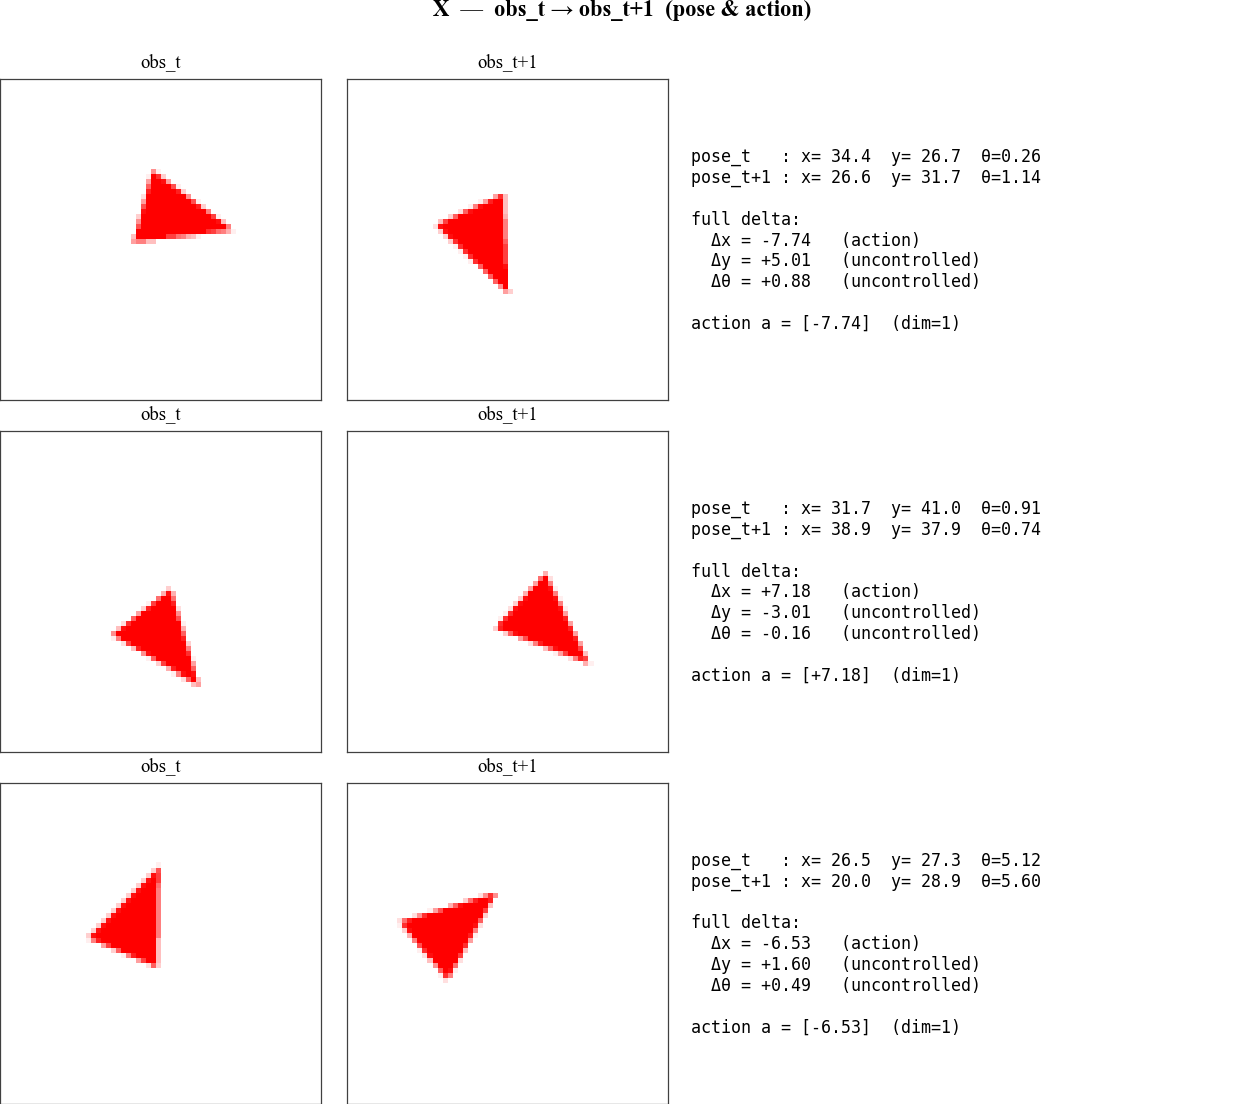

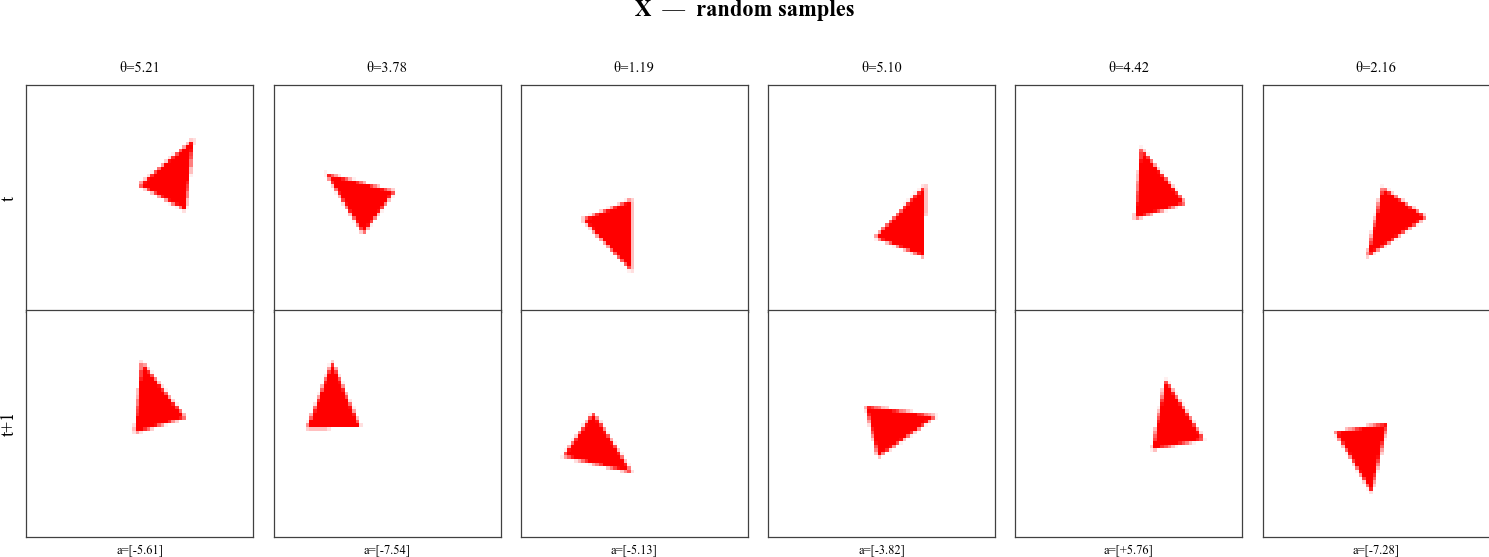

SpriteWorldConfig  |  64×64 px  |  shape=ARROW  sprite_scale=7.5  |  control=X (x)  |  action_dim=1
  max_delta: xy=8.0 px  θ=1.067 rad  |  bounding_radius=12 px  margin=21 px 



In [6]:
cfg_x = make_sprite_config(ControlConfig.X)
ds_x = SpriteWorldDataset(cfg_x, num_samples=200, seed=0)

show_transitions_annotated(ds_x, indices=[0, 1, 2],
                           title="X  —  obs_t → obs_t+1  (pose & action)")
plot_random_grid(ds_x, n_cols=6, seed=10,
                 title="X  —  random samples")

## 3 — `XY`

**x** and **y** controlled — `action_dim = 2`. θ still rotates (uncontrolled).

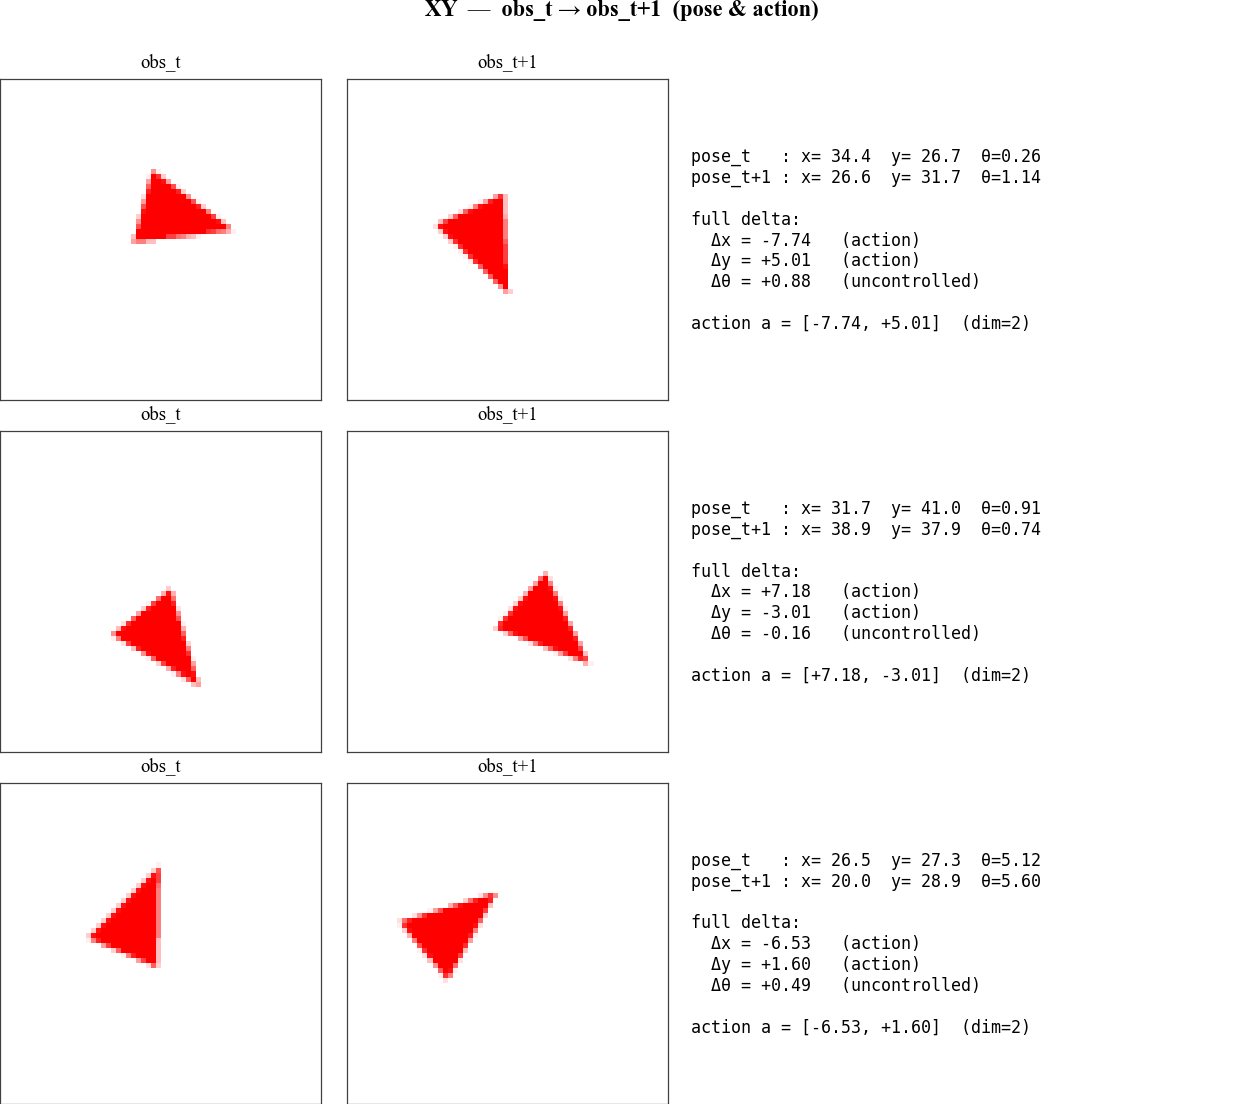

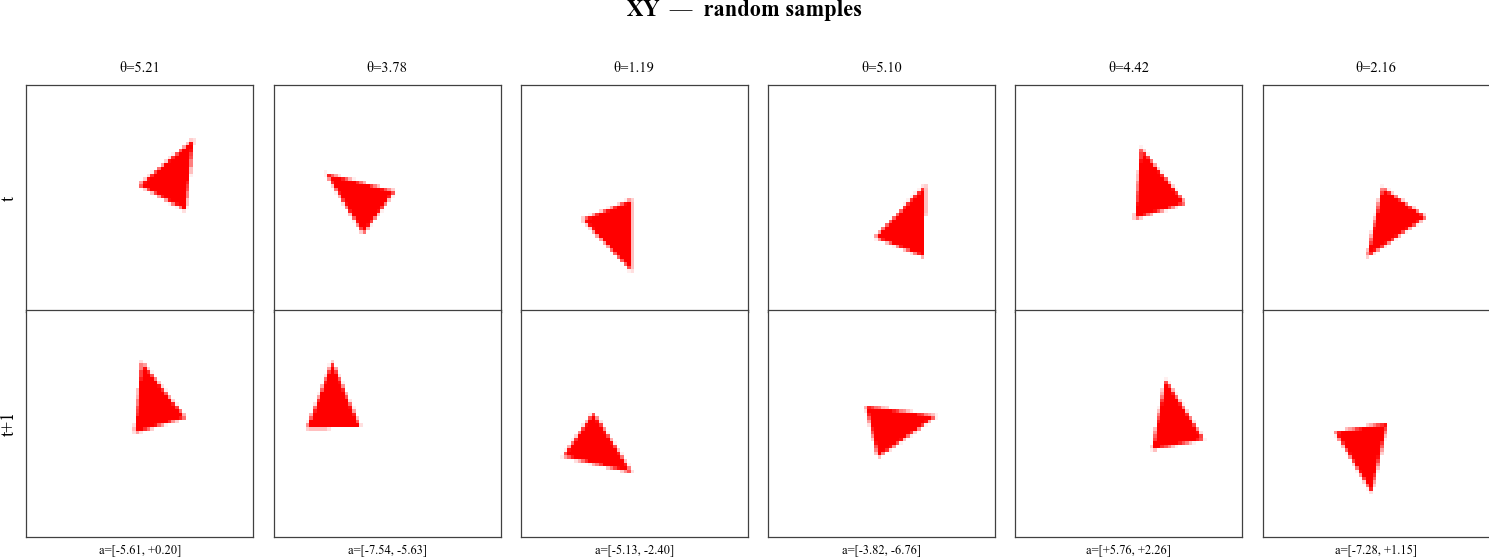

SpriteWorldConfig  |  64×64 px  |  shape=ARROW  sprite_scale=7.5  |  control=XY (x,y)  |  action_dim=2
  max_delta: xy=8.0 px  θ=1.067 rad  |  bounding_radius=12 px  margin=21 px 



In [7]:
cfg_xy = make_sprite_config(ControlConfig.XY)
ds_xy = SpriteWorldDataset(cfg_xy, num_samples=200, seed=0)

show_transitions_annotated(ds_xy, indices=[0, 1, 2],
                           title="XY  —  obs_t → obs_t+1  (pose & action)")
plot_random_grid(ds_xy, n_cols=6, seed=10,
                 title="XY  —  random samples")

## 4 — `XYT`

All DOFs controlled — `action_dim = 3`. The action fully explains the transition.

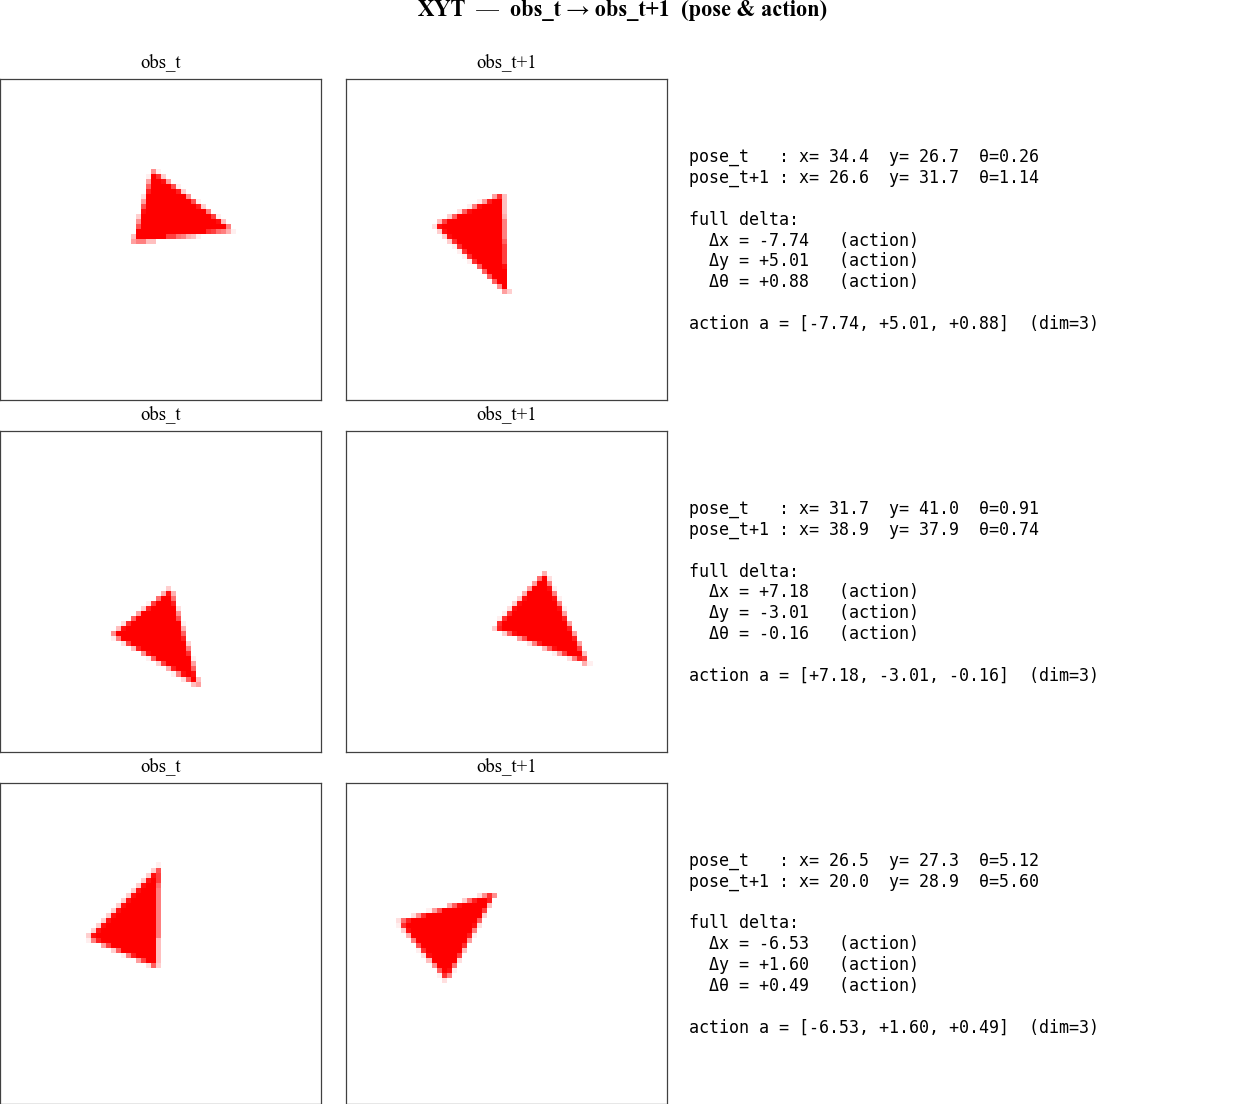

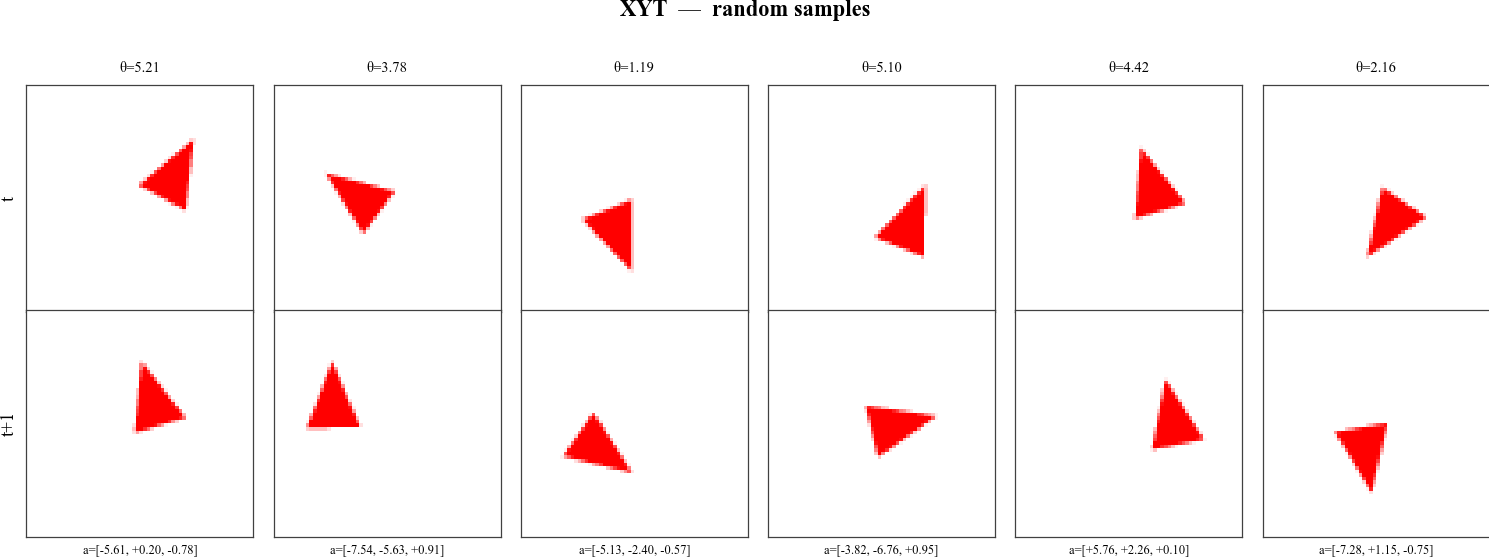

SpriteWorldConfig  |  64×64 px  |  shape=ARROW  sprite_scale=7.5  |  control=XYT (x,y,θ)  |  action_dim=3
  max_delta: xy=8.0 px  θ=1.067 rad  |  bounding_radius=12 px  margin=21 px 



In [8]:
cfg_xyt = make_sprite_config(ControlConfig.XYT)
ds_xyt = SpriteWorldDataset(cfg_xyt, num_samples=200, seed=0)

show_transitions_annotated(ds_xyt, indices=[0, 1, 2],
                           title="XYT  —  obs_t → obs_t+1  (pose & action)")
plot_random_grid(ds_xyt, n_cols=6, seed=10,
                 title="XYT  —  random samples")

## Trajectory rollout — controlled vs. uncontrolled motion

Continuous rollout under config **X**: only Δx enters the action, yet the arrow
clearly **translates in y and rotates** as well. This is the uncontrolled
motion the encoder is meant to learn to ignore. θ wraps at 2π.

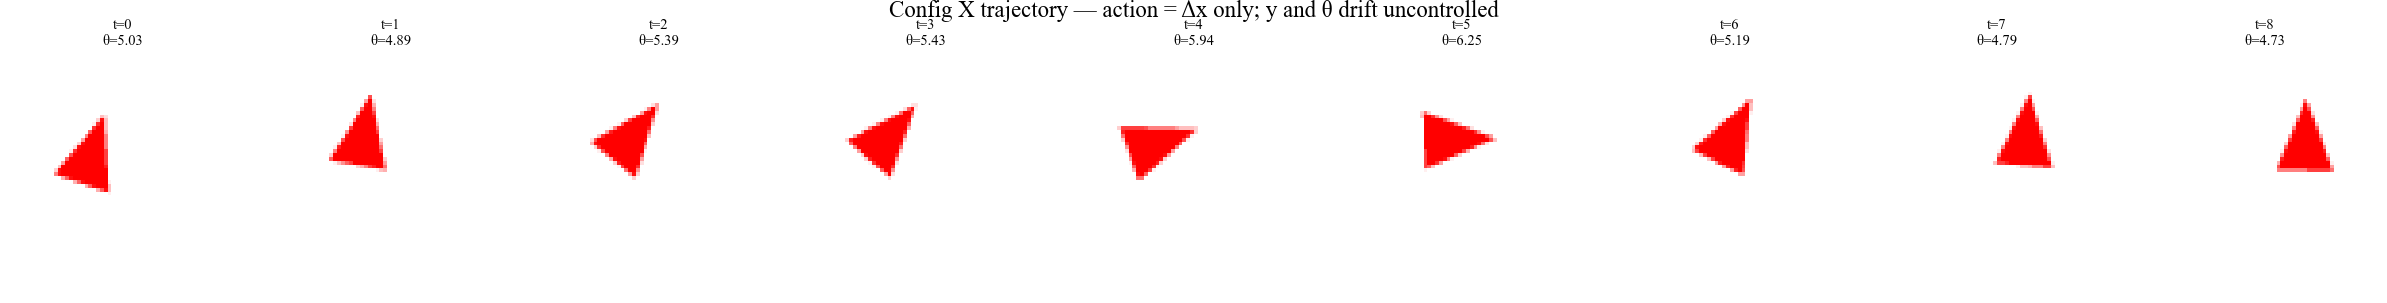

step       x      y      θ   action (Δx, controlled)
--------------------------------------------------
   0    22.8   26.0   5.03   +1.31
   1    24.1   21.0   4.89   -0.34
   2    23.8   21.0   5.39   -6.18
   3    21.0   21.0   5.43   -1.11
   4    21.0   22.4   5.94   +7.30
   5    28.3   21.0   6.25   +3.14
   6    31.4   21.0   5.19   +7.58
   7    39.0   21.0   4.79   +6.27
   8    42.0   22.4   4.73       —


In [9]:
cfg_traj = make_sprite_config(ControlConfig.X)
obs, actions, states = generate_trajectory(cfg_traj, num_steps=8, seed=3)

T = obs.shape[0]
fig, axes = plt.subplots(1, T, figsize=(1.8 * T, 2.2))
fig.suptitle("Config X trajectory — action = Δx only; y and θ drift uncontrolled",
             fontsize=11)
for t in range(T):
    axes[t].imshow(obs[t].transpose(1, 2, 0), interpolation="nearest")
    axes[t].set_title(f"t={t}\nθ={states[t, 2]:.2f}", fontsize=7)
    axes[t].axis("off")
plt.tight_layout()
plt.show()

print(f"{'step':>4}  {'x':>6} {'y':>6} {'θ':>6}   action (Δx, controlled)")
print("-" * 50)
for t in range(T):
    a = f"{actions[t][0]:+.2f}" if t < len(actions) else "    —"
    print(f"{t:>4}  {states[t,0]:6.1f} {states[t,1]:6.1f} {states[t,2]:6.2f}   {a}")

## DataLoader / batch-contract check

The dataset returns the same 4-tuple `train.py` unpacks:
`obs_t, action, obs_tp1, state_t`. `state_t` is the (x, y, θ) pose — the analog
of `positions_t` in the structured-dot world.

In [10]:
ds_check = SpriteWorldDataset(make_sprite_config(ControlConfig.XYT),
                             num_samples=64, seed=0)
loader = DataLoader(ds_check, batch_size=16, shuffle=True, num_workers=0)
obs_t, action, obs_tp1, state_t = next(iter(loader))   # matches train.py unpack

print("obs_t   :", tuple(obs_t.shape),   obs_t.dtype)
print("action  :", tuple(action.shape),  action.dtype, " (action_dim =",
      ds_check.config.action_dim, ")")
print("obs_tp1 :", tuple(obs_tp1.shape), obs_tp1.dtype)
print("state_t :", tuple(state_t.shape), state_t.dtype, " (x, y, θ)")
print("action_scale (per-DOF norm):", np.round(ds_check.config.action_scale, 3))

obs_t   : (16, 3, 64, 64) torch.float32
action  : (16, 3) torch.float32  (action_dim = 3 )
obs_tp1 : (16, 3, 64, 64) torch.float32
state_t : (16, 3) torch.float32  (x, y, θ)
action_scale (per-DOF norm): [8.    8.    1.067]
